In [ ]:
**** Questão 02 ****

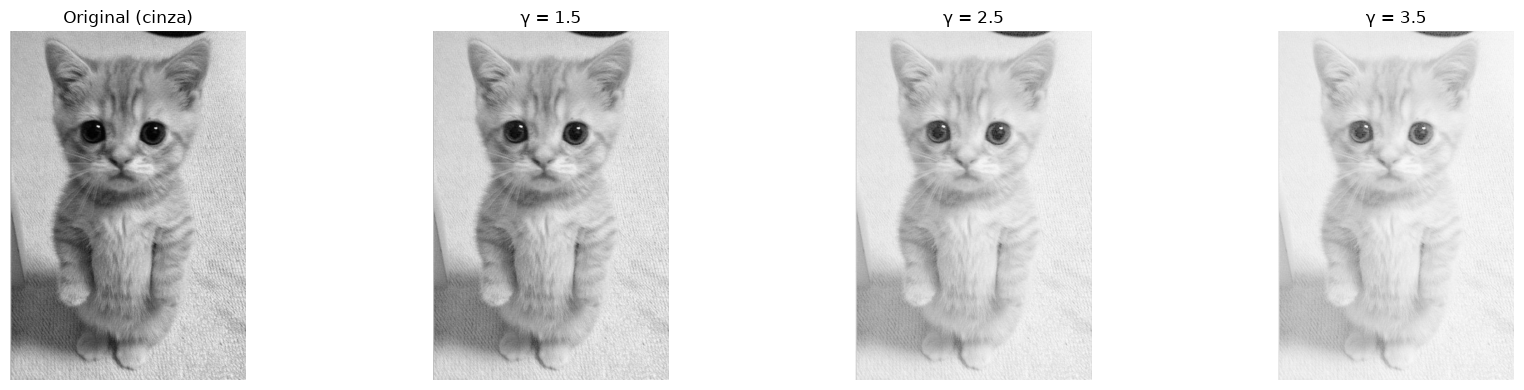

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Carregamento (permitido pelas regras)
imagem_bgr = cv2.imread('cat so.jpg')
if imagem_bgr is None:
    raise FileNotFoundError("Não achei a imagem, confere o nome e a pasta")

# Conversão manual para tons de cinza (luminância)
canal_azul = imagem_bgr[:, :, 0]
canal_verde = imagem_bgr[:, :, 1]
canal_vermelho = imagem_bgr[:, :, 2]
imagem_cinza = 0.299 * canal_vermelho + 0.587 * canal_verde + 0.114 * canal_azul


def correcao_gama_manual(imagem_entrada, valor_gama):
    # (i) [0, 255] -> [0, 1]
    imagem_normalizada = imagem_entrada / 255.0
    # (ii) B = A^(1/gama)
    imagem_corrigida = imagem_normalizada ** (1.0 / valor_gama)
    # (iii) [0, 1] -> [0, 255]
    return np.clip(np.round(imagem_corrigida * 255.0), 0, 255).astype(np.uint8)


lista_gamas = [ 1.5, 2.5, 3.5]
resultados = {gama: correcao_gama_manual(imagem_cinza, gama) for gama in lista_gamas}

# Comparação visual com escala fixa
plt.figure(figsize=(18, 4))
plt.subplot(1, len(lista_gamas) + 1, 1)
plt.imshow(imagem_cinza, cmap='gray', vmin=0, vmax=255)
plt.title('Original (cinza)')
plt.axis('off')

for posicao, gama in enumerate(lista_gamas, start=2):
    plt.subplot(1, len(lista_gamas) + 1, posicao)
    plt.imshow(resultados[gama], cmap='gray', vmin=0, vmax=255)
    plt.title(f'γ = {gama}')
    plt.axis('off')

plt.tight_layout()
plt.savefig('comparacao_gama.png', dpi=150)  # pra colocar no PDF
plt.show()

In [ ]:
**** Questão 04 ****

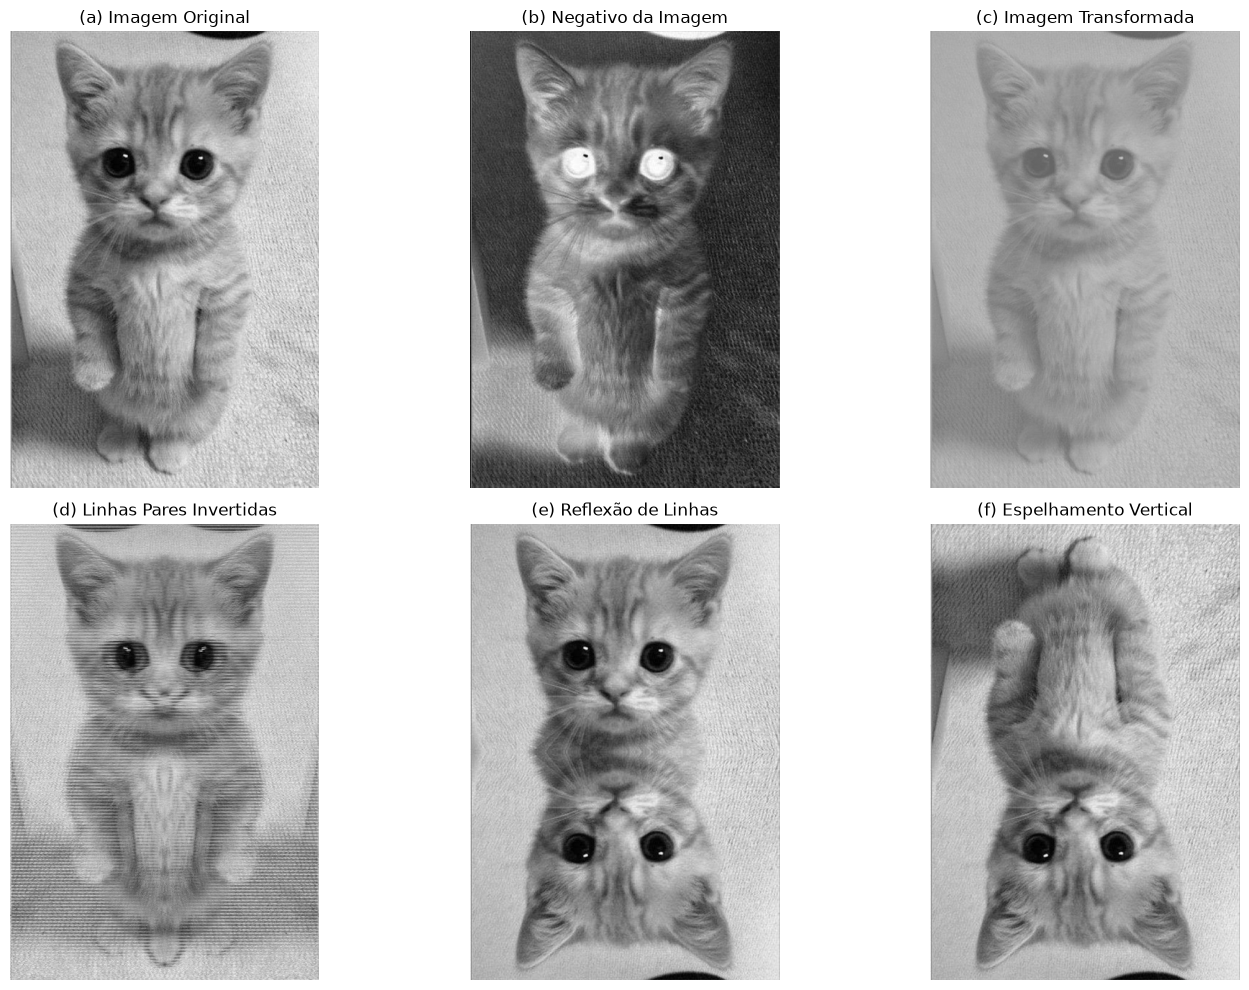

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# QUESTÃO 04: Transformações e Manipulações Espaciais Manuais
# ==============================================================================

NOME_DA_IMAGEM = 'cat so.jpg'  # troque pela imagem do tema do seu trabalho final


# ------------------------------------------------------------------------------
# 1. Carregamento da imagem (OpenCV permitido apenas para carregar/salvar)
# ------------------------------------------------------------------------------
imagem_bgr = cv2.imread(NOME_DA_IMAGEM)
if imagem_bgr is None:
    raise FileNotFoundError(
        f"Imagem '{NOME_DA_IMAGEM}' não encontrada! Verifique o nome e a pasta."
    )


# ------------------------------------------------------------------------------
# 2. Conversão MANUAL para tons de cinza (luminância)
#    Y = 0.299*R + 0.587*G + 0.114*B
# ------------------------------------------------------------------------------
def converter_para_cinza(imagem_colorida_bgr):
    canal_azul = imagem_colorida_bgr[:, :, 0].astype(np.float64)
    canal_verde = imagem_colorida_bgr[:, :, 1].astype(np.float64)
    canal_vermelho = imagem_colorida_bgr[:, :, 2].astype(np.float64)

    luminancia = 0.299 * canal_vermelho + 0.587 * canal_verde + 0.114 * canal_azul
    return np.clip(np.round(luminancia), 0, 255).astype(np.uint8)


imagem_original = converter_para_cinza(imagem_bgr)
altura, largura = imagem_original.shape


# ------------------------------------------------------------------------------
# (b) Negativo da imagem: nível 0 -> 255, nível 1 -> 254, ...
#     Fórmula: negativo = 255 - pixel
# ------------------------------------------------------------------------------
imagem_negativo = (255 - imagem_original).astype(np.uint8)


# ------------------------------------------------------------------------------
# (c) Converter o intervalo de intensidades para [100, 200]
#     Mapeamento linear: menor valor -> 100 e maior valor -> 200
# ------------------------------------------------------------------------------
menor_intensidade = float(np.min(imagem_original))
maior_intensidade = float(np.max(imagem_original))

if maior_intensidade != menor_intensidade:
    proporcao_normalizada = (
        (imagem_original.astype(np.float64) - menor_intensidade)
        / (maior_intensidade - menor_intensidade)
    )
    imagem_intervalo = 100.0 + proporcao_normalizada * 100.0
else:
    # Imagem com um único tom: todos os pixels vão para o início do intervalo
    imagem_intervalo = np.full((altura, largura), 100.0)

imagem_intervalo = np.round(imagem_intervalo).astype(np.uint8)


# ------------------------------------------------------------------------------
# (d) Inverter os pixels das linhas pares (direita -> esquerda)
#     Linhas 0, 2, 4, ... têm suas colunas invertidas; as ímpares ficam iguais.
#     Lê sempre da imagem original para não misturar origem e destino.
# ------------------------------------------------------------------------------
imagem_linhas_pares_invertidas = imagem_original.copy()
imagem_linhas_pares_invertidas[0::2, :] = imagem_original[0::2, ::-1]


# ------------------------------------------------------------------------------
# (e) Espelhar as linhas da metade superior na parte inferior
#     A última linha recebe a linha 0, a penúltima recebe a linha 1, etc.
#     Se a altura for ímpar, a linha do meio permanece como está.
# ------------------------------------------------------------------------------
linhas_na_metade = altura // 2
imagem_reflexao_de_linhas = imagem_original.copy()
imagem_reflexao_de_linhas[altura - linhas_na_metade:, :] = (
    imagem_original[0:linhas_na_metade, :][::-1, :]
)


# ------------------------------------------------------------------------------
# (f) Espelhamento vertical considerando todas as linhas da imagem
#     A linha 0 vai para a última posição, a linha 1 para a penúltima, etc.
# ------------------------------------------------------------------------------
imagem_espelhamento_vertical = imagem_original[::-1, :].copy()


# ==============================================================================
# Exibição dos resultados (grade 2x3 para o relatório)
# ==============================================================================
titulos = [
    '(a) Imagem Original',
    '(b) Negativo da Imagem',
    '(c) Imagem Transformada',
    '(d) Linhas Pares Invertidas',
    '(e) Reflexão de Linhas',
    '(f) Espelhamento Vertical',
]

imagens = [
    imagem_original,
    imagem_negativo,
    imagem_intervalo,
    imagem_linhas_pares_invertidas,
    imagem_reflexao_de_linhas,
    imagem_espelhamento_vertical,
]

plt.figure(figsize=(15, 10))

for indice_imagem in range(len(imagens)):
    plt.subplot(2, 3, indice_imagem + 1)
    # vmin/vmax fixos mantêm a mesma escala de cinza em todas as imagens
    plt.imshow(imagens[indice_imagem], cmap='gray', vmin=0, vmax=255)
    plt.title(titulos[indice_imagem], fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.savefig('questao_04_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
**** Questão 06 **** 

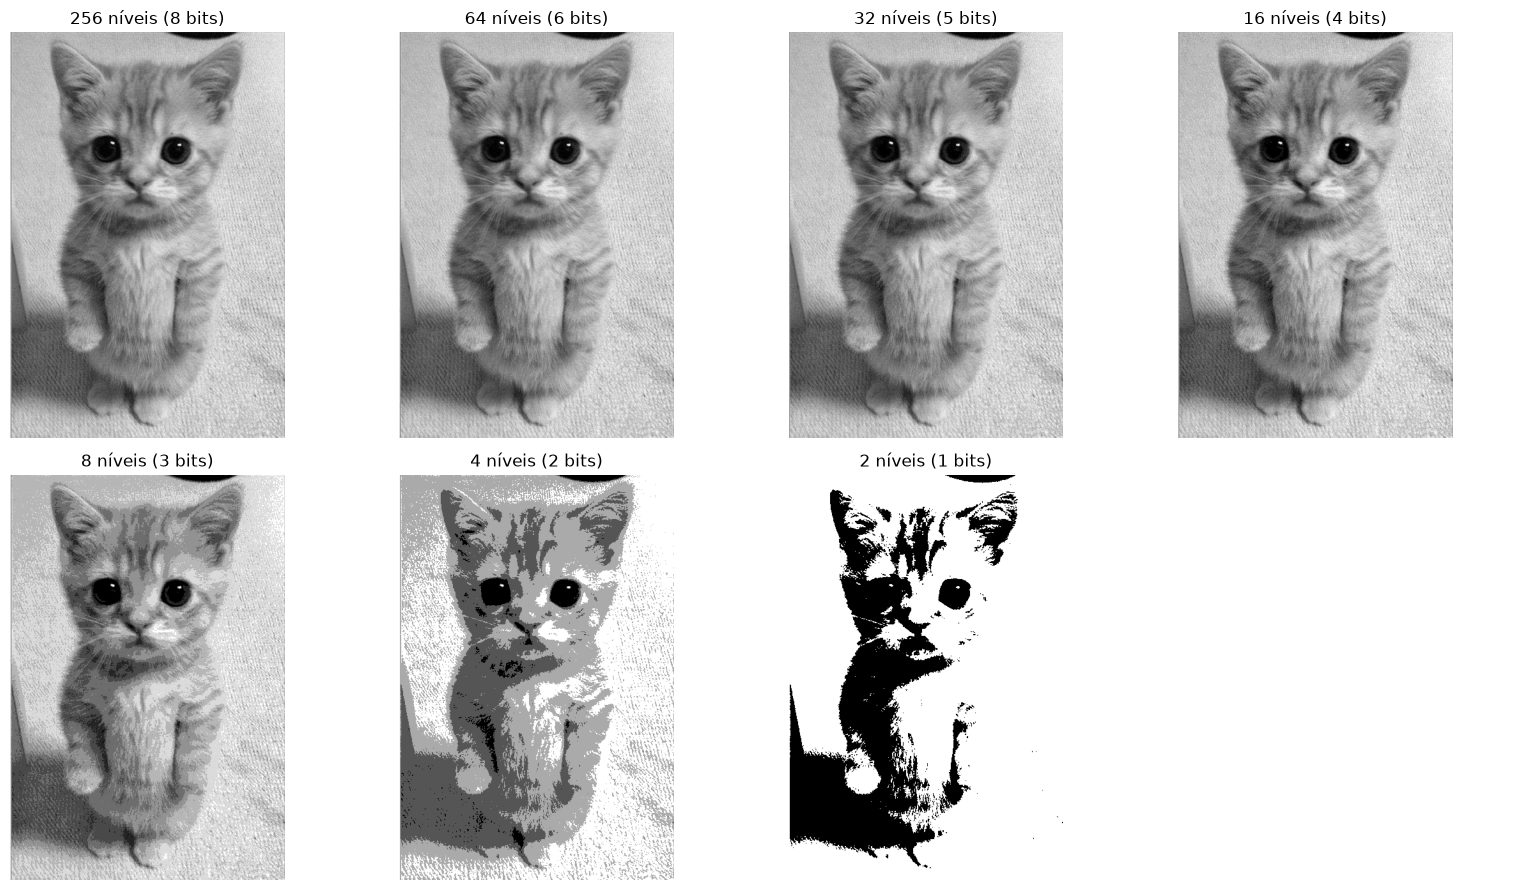

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# QUESTÃO 06: Quantização de Imagem Monocromática (diferentes níveis de cinza)
# ==============================================================================

NOME_DA_IMAGEM = 'cat so.jpg'  # troque pela imagem do tema do seu trabalho final


# ------------------------------------------------------------------------------
# 1. Carregamento da imagem (OpenCV permitido apenas para carregar/salvar)
# ------------------------------------------------------------------------------
imagem_bgr = cv2.imread(NOME_DA_IMAGEM)
if imagem_bgr is None:
    raise FileNotFoundError(
        f"Imagem '{NOME_DA_IMAGEM}' não encontrada! Verifique o nome e a pasta."
    )


# ------------------------------------------------------------------------------
# 2. Conversão MANUAL para tons de cinza (luminância)
#    Y = 0.299*R + 0.587*G + 0.114*B
# ------------------------------------------------------------------------------
def converter_para_cinza(imagem_colorida_bgr):
    canal_azul = imagem_colorida_bgr[:, :, 0].astype(np.float64)
    canal_verde = imagem_colorida_bgr[:, :, 1].astype(np.float64)
    canal_vermelho = imagem_colorida_bgr[:, :, 2].astype(np.float64)

    luminancia = 0.299 * canal_vermelho + 0.587 * canal_verde + 0.114 * canal_azul
    return np.clip(np.round(luminancia), 0, 255).astype(np.uint8)


imagem_original = converter_para_cinza(imagem_bgr)


# ------------------------------------------------------------------------------
# 3. Quantização manual
#    Passo 1: divide os 256 tons em "quantidade_de_niveis" faixas iguais.
#    Passo 2: descobre em qual faixa cada pixel caiu (0, 1, 2, ...).
#    Passo 3: troca o pixel pelo tom representante da faixa, espalhando
#             os tons de saída de 0 até 255 (assim o preto e o branco
#             sempre aparecem na imagem quantizada).
# ------------------------------------------------------------------------------
def quantizar_imagem(imagem_cinza, quantidade_de_niveis):
    # int32 evita estouro do uint8 na multiplicação abaixo
    pixels_inteiros = imagem_cinza.astype(np.int32)

    # Passo 1 e 2: índice da faixa de cada pixel (0 até quantidade_de_niveis - 1)
    indice_da_faixa = (pixels_inteiros * quantidade_de_niveis) // 256

    # Passo 3: tom de saída de cada faixa, entre 0 e 255
    espacamento_entre_tons = 255.0 / (quantidade_de_niveis - 1)
    imagem_quantizada = np.round(indice_da_faixa * espacamento_entre_tons)

    return imagem_quantizada.astype(np.uint8)


# ------------------------------------------------------------------------------
# 4. Aplicação com diferentes números de níveis
# ------------------------------------------------------------------------------
lista_de_niveis = [256, 64, 32, 16, 8, 4, 2]

resultados = {}
for quantidade_de_niveis in lista_de_niveis:
    resultados[quantidade_de_niveis] = quantizar_imagem(
        imagem_original, quantidade_de_niveis
    )


# ------------------------------------------------------------------------------
# 5. Exibição dos resultados (grade para o relatório)
# ------------------------------------------------------------------------------
numero_de_colunas = 4
numero_de_linhas = 2

figura, eixos = plt.subplots(numero_de_linhas, numero_de_colunas, figsize=(16, 9))
eixos = eixos.ravel()

for posicao, quantidade_de_niveis in enumerate(lista_de_niveis):
    bits_por_pixel = int(np.log2(quantidade_de_niveis))
    eixos[posicao].imshow(
        resultados[quantidade_de_niveis], cmap='gray', vmin=0, vmax=255
    )
    eixos[posicao].set_title(f'{quantidade_de_niveis} níveis ({bits_por_pixel} bits)')
    eixos[posicao].axis('off')

# Esconde os eixos que sobraram na grade
for posicao in range(len(lista_de_niveis), len(eixos)):
    eixos[posicao].axis('off')

plt.tight_layout()
plt.savefig('questao_06_resultados.png', dpi=150, bbox_inches='tight')
plt.show()